# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

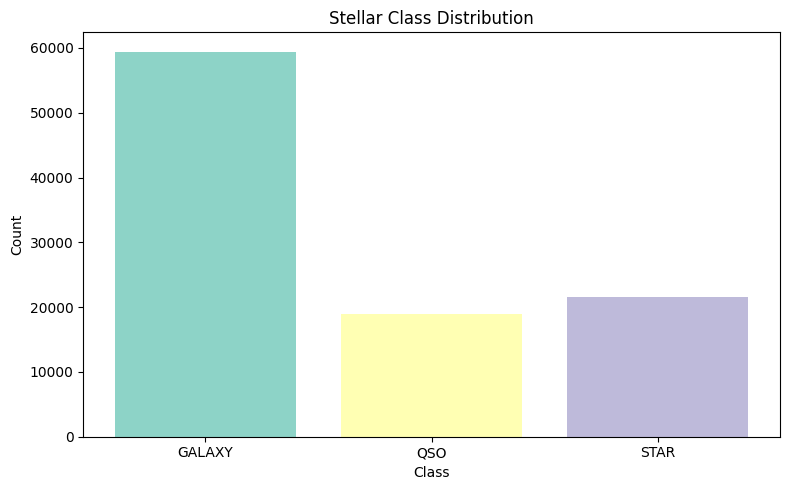

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [4]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [5]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [6]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.77%  P=0.80  R=0.82  F1=0.81
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.36%  P=0.88  R=0.88  F1=0.88
CatBoost trained.
  [Training] Acc=93.17%  P=0.93  R=0.93  F1=0.93
  [Validation] Acc=90.23%  P=0.87  R=0.88  F1=0.87
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002790 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM trained.


/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=91.31%  P=0.91  R=0.91  F1=0.91
  [Validation] Acc=90.05%  P=0.87  R=0.88  F1=0.87


In [7]:
# Train Voting Classifier utilizing the trained models
voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.


/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=95.55%  P=0.96  R=0.96  F1=0.96
  [Validation] Acc=90.44%  P=0.88  R=0.88  F1=0.88


/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [8]:
# Train PyTorch Neural Network
input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

nn_model = sc.train_neural(
    train_loader=train_loader,
    val_loader=val_loader,
    input_size=input_size,
    num_classes=num_classes,
    num_epochs=10,
    lr=0.001
)


Epoch  1/10  loss=0.4903  val_acc=84.66%
Epoch  2/10  loss=0.4181  val_acc=86.25%
Epoch  3/10  loss=0.3987  val_acc=86.48%
Epoch  4/10  loss=0.3851  val_acc=87.30%
Epoch  5/10  loss=0.3749  val_acc=86.80%
Epoch  6/10  loss=0.3671  val_acc=87.41%
Epoch  7/10  loss=0.3596  val_acc=87.69%
Epoch  8/10  loss=0.3544  val_acc=86.91%
Epoch  9/10  loss=0.3491  val_acc=87.47%
Epoch 10/10  loss=0.3449  val_acc=87.29%


In [10]:
# Base inference on test set
import torch 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)


/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Voting Classifier:
  Accuracy  : 90.85%
  Precision: 0.8815
  Recall   : 0.8855
  F1       : 0.8827
  Confusion Matrix:
[[10204   361   216]
 [  222  3114   212]
 [  273   386  3269]]

Neural Network:
  Accuracy  : 87.66%
  Precision: 0.8383
  Recall   : 0.8588
  F1       : 0.8476
  Confusion Matrix:
[[9771  445  565]
 [ 213 3058  277]
 [ 314  439 3175]]


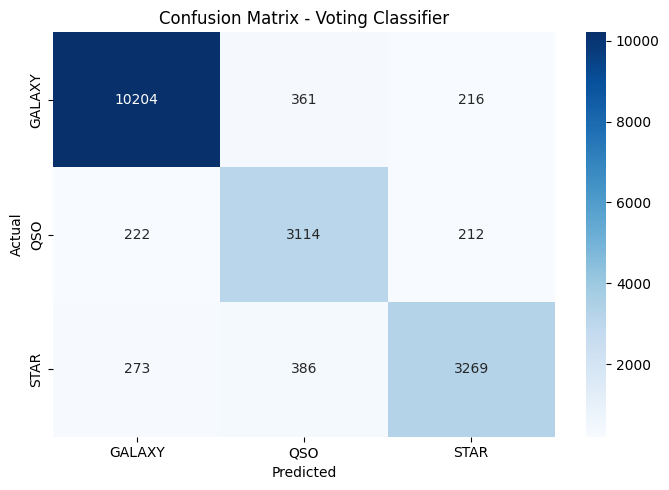

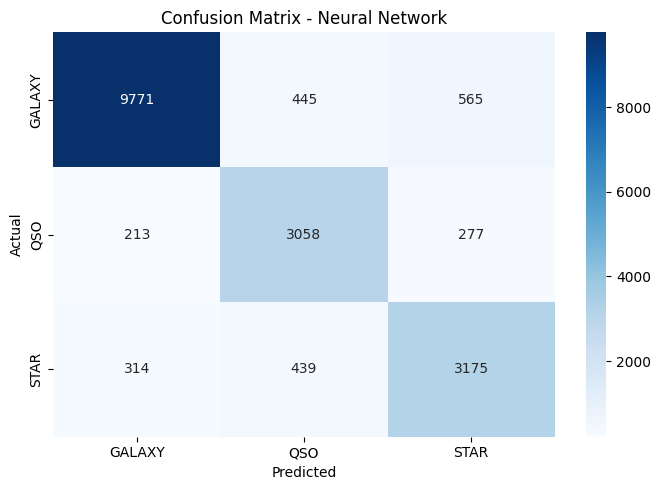

In [11]:
# Confusion Matrices
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/miniconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

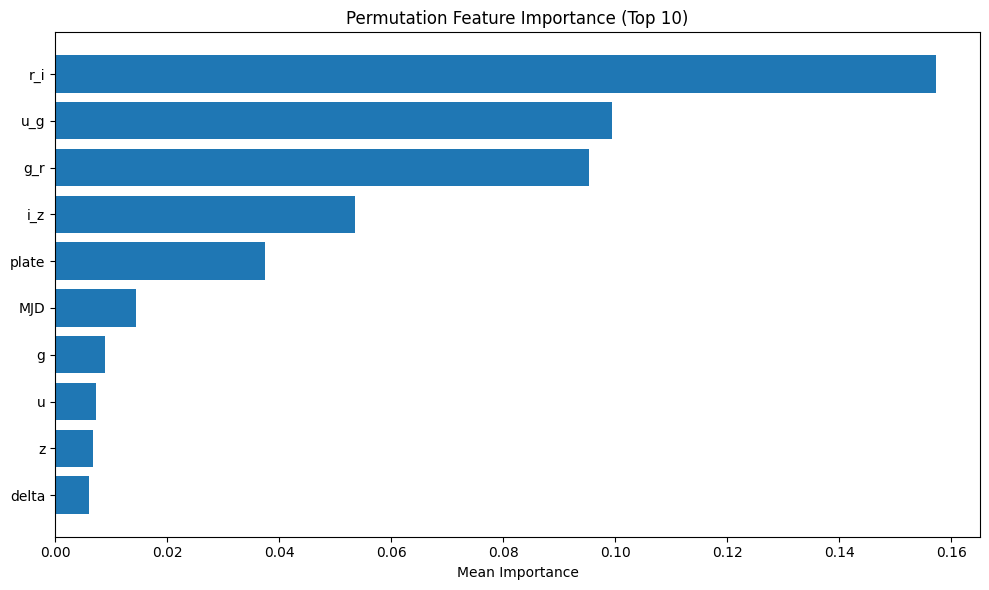

Feature Importance Scores:
r_i: 0.1573
u_g: 0.0995
g_r: 0.0953
i_z: 0.0536
plate: 0.0375
MJD: 0.0144
g: 0.0089
u: 0.0072
z: 0.0068
delta: 0.0060
alpha: 0.0057
i: 0.0043
r: 0.0037


In [12]:
# Feature Importance (using permutation importance on the Voting Classifier)
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")
